# Milestone 3: EDA and Baseline Modeling

**Course:** CS109B Deep Learning

**Canvas Project Number:** 25

**Group Members:** Sam Chung, Anthony Shen, Lewis Tu, Allie Zong

## Table of Contents

- [1. Introduction and Refined Problem Statement](#1-introduction-and-refined-problem-statement)
- [2. Data Description](#2-data-description)
- [3. Recap of Milestone 2](#3-recap-of-milestone-2)
- [4. Key EDA Visual Review (from Milestone 2)](#4-key-eda-visual-review-from-milestone-2)
- [5. Setup and Reproducibility](#5-setup-and-reproducibility)
- [6. Data Loading and Time-Aware Split](#6-data-loading-and-time-aware-split)
- [7. Feature Engineering Recap and Preprocessing](#7-feature-engineering-recap-and-preprocessing)
- [8. Simple 1090A Baselines](#8-simple-1090a-baselines)
- [9. 1090B Baseline: FeedForward Neural Network](#9-1090b-baseline-feedforward-neural-network)
- [10. Results and Interpretation](#10-results-and-interpretation)
- [11. Final Model Pipeline Setup](#11-final-model-pipeline-setup)
- [12. Future Directions](#12-future-directions)

## 1. Introduction and Refined Problem Statement

Electricity market prices are high-impact targets because they influence bidding strategy, generation dispatch, grid operations, and downstream consumer costs. In this project, we focus on PJM day-ahead electricity prices and establish a baseline model before exploring more advanced temporal deep learning architectures.

**Finalized Research Question**

How accurately can we predict PJM day-ahead electricity prices using a neural network trained on available historical market and system data?

## 2. Data Description

This notebook uses the cleaned tabular dataset saved as initial_data.csv from the prior preprocessing notebook. Each row corresponds to one hourly timestamp and includes:

- **Target variable:** price (PJM day-ahead total LMP).
- **Demand-side context:** load forecast (load_forecast_mw).
- **Supply-side context:** generation by fuel type and outage forecasts.
- **Calendar features:** hour, day-of-week, month, weekend/holiday indicators, season.
- **Cyclical encodings:** sine/cosine transforms for hour and day-of-week.
- **Lag/derived features:** lagged prices, renewable total, rolling mean.

## 3. Recap of Milestone 2

Milestone 2 completed data wrangling and EDA. The findings below directly shaped baseline model design for Milestone 3:

- The price distribution is right-skewed with occasional spikes, so we evaluate with both MAE (typical error) and RMSE (spike-sensitive error).
- Strong intraday and weekly structure supported explicit calendar and cyclical features (`hour`, `day_of_week`, sine/cosine terms).
- Lagged prices showed high signal (especially lag-1 and lag-24 in EDA), motivating both a persistence benchmark and lag-based tabular baselines.
- Load forecast, outages, and generation mix displayed meaningful relationships with price, justifying inclusion of supply-demand system features in the baseline feature set.

**Modeling implications carried into Milestone 3**

- Use a strict chronological train/validation/test split to avoid future leakage.
- Start with baseline hierarchy: Persistence -> Ridge -> Random Forest -> PyTorch MLP.
- Use a feedforward neural network as the primary 109B deep learning baseline before more complex sequence-aware models.

## 4. Key EDA Visual Review (from Milestone 2)

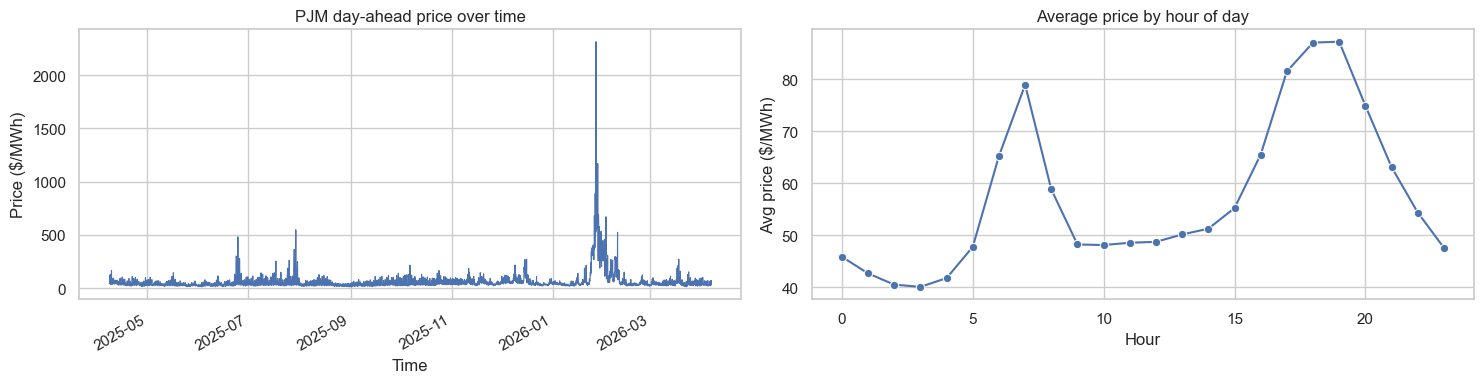

In [14]:
# 4.2 Temporal patterns: full timeline and average hour profile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if "eda_df" not in globals():
    eda_df = pd.read_csv("initial_data.csv")
    eda_df["datetime_beginning_ept"] = pd.to_datetime(eda_df["datetime_beginning_ept"])
    eda_df = eda_df.sort_values("datetime_beginning_ept").set_index("datetime_beginning_ept")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

eda_df["price"].plot(ax=axes[0], linewidth=0.8)
axes[0].set_title("PJM day-ahead price over time")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Price ($/MWh)")

hourly_profile = eda_df.groupby("hour")["price"].mean()
sns.lineplot(x=hourly_profile.index, y=hourly_profile.values, marker="o", ax=axes[1])
axes[1].set_title("Average price by hour of day")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Avg price ($/MWh)")

plt.tight_layout()
plt.show()

Correlation(price, price_lag_1):  0.946
Correlation(price, price_lag_24): 0.814


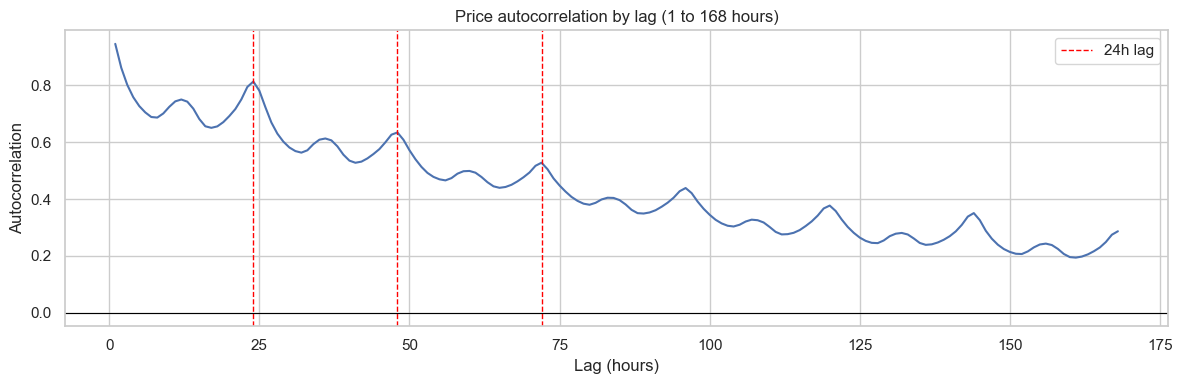

In [16]:
# 4.4 Autocorrelation diagnostics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if "eda_df" not in globals():
    eda_df = pd.read_csv("initial_data.csv")
    eda_df["datetime_beginning_ept"] = pd.to_datetime(eda_df["datetime_beginning_ept"])
    eda_df = eda_df.sort_values("datetime_beginning_ept").set_index("datetime_beginning_ept")

lag1_corr = eda_df[["price", "price_lag_1"]].corr().iloc[0, 1]
lag24_corr = eda_df[["price", "price_lag_24"]].corr().iloc[0, 1]
print(f"Correlation(price, price_lag_1):  {lag1_corr:.3f}")
print(f"Correlation(price, price_lag_24): {lag24_corr:.3f}")

max_lag = 24 * 7
lags = np.arange(1, max_lag + 1)
acf_vals = [eda_df["price"].autocorr(lag=i) for i in lags]

plt.figure(figsize=(12, 4))
sns.lineplot(x=lags, y=acf_vals)
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(24, color="red", linestyle="--", linewidth=1, label="24h lag")
plt.axvline(48, color="red", linestyle="--", linewidth=1)
plt.axvline(72, color="red", linestyle="--", linewidth=1)
plt.title("Price autocorrelation by lag (1 to 168 hours)")
plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation")
plt.legend()
plt.tight_layout()
plt.show()

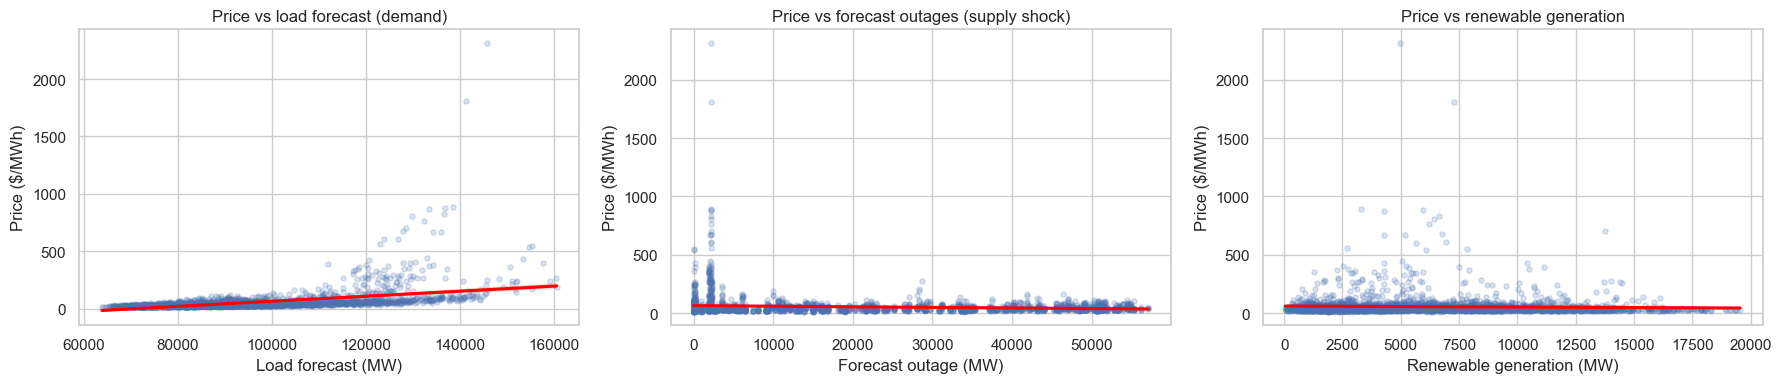

In [15]:
# 4.3 Supply and demand vs price
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if "eda_df" not in globals():
    eda_df = pd.read_csv("initial_data.csv")
    eda_df["datetime_beginning_ept"] = pd.to_datetime(eda_df["datetime_beginning_ept"])
    eda_df = eda_df.sort_values("datetime_beginning_ept").set_index("datetime_beginning_ept")

sampled = eda_df.sample(min(len(eda_df), 3000), random_state=42)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.regplot(
    data=sampled, x="load_forecast_mw", y="price",
    scatter_kws={"alpha": 0.2, "s": 14}, line_kws={"color": "red"}, ax=axes[0]
 )
axes[0].set_title("Price vs load forecast (demand)")
axes[0].set_xlabel("Load forecast (MW)")
axes[0].set_ylabel("Price ($/MWh)")

sns.regplot(
    data=sampled, x="forecast_gen_outage_mw_rto", y="price",
    scatter_kws={"alpha": 0.2, "s": 14}, line_kws={"color": "red"}, ax=axes[1]
 )
axes[1].set_title("Price vs forecast outages (supply shock)")
axes[1].set_xlabel("Forecast outage (MW)")
axes[1].set_ylabel("Price ($/MWh)")

sns.regplot(
    data=sampled, x="renewable_mw", y="price",
    scatter_kws={"alpha": 0.2, "s": 14}, line_kws={"color": "red"}, ax=axes[2]
 )
axes[2].set_title("Price vs renewable generation")
axes[2].set_xlabel("Renewable generation (MW)")
axes[2].set_ylabel("Price ($/MWh)")

plt.tight_layout()
plt.show()

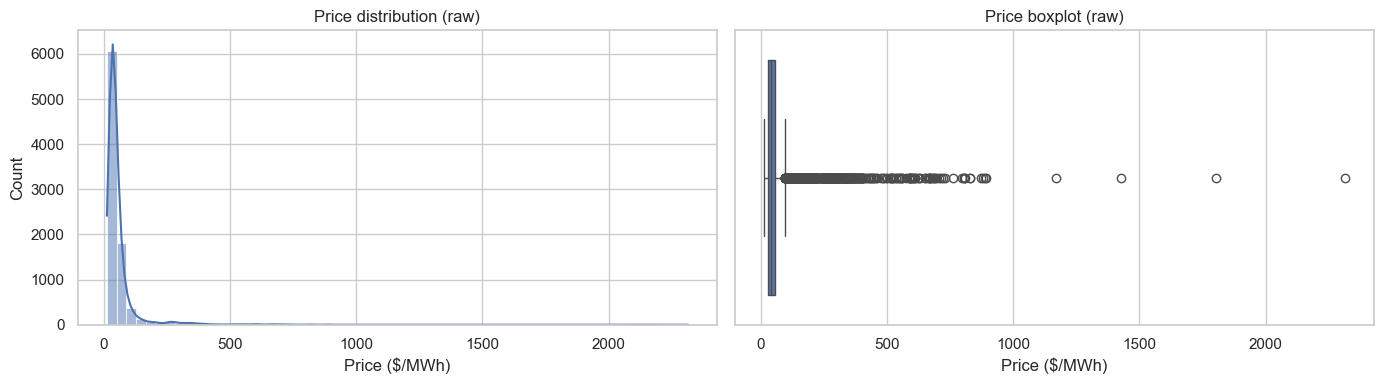

In [13]:
# 4.1 Target variable analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if "eda_df" not in globals():
    eda_df = pd.read_csv("initial_data.csv")
    eda_df["datetime_beginning_ept"] = pd.to_datetime(eda_df["datetime_beginning_ept"])
    eda_df = eda_df.sort_values("datetime_beginning_ept").set_index("datetime_beginning_ept")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(eda_df["price"], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Price distribution (raw)")
axes[0].set_xlabel("Price ($/MWh)")

sns.boxplot(x=eda_df["price"], ax=axes[1])
axes[1].set_title("Price boxplot (raw)")
axes[1].set_xlabel("Price ($/MWh)")

plt.tight_layout()
plt.show()

In [12]:
# 4.0 EDA helper data (self-contained for robust re-runs)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

eda_df = pd.read_csv("initial_data.csv")
eda_df["datetime_beginning_ept"] = pd.to_datetime(eda_df["datetime_beginning_ept"])
eda_df = eda_df.sort_values("datetime_beginning_ept").set_index("datetime_beginning_ept")

# Visual clipping aid (raw series is still used for core analysis)
q01, q99 = eda_df["price"].quantile([0.01, 0.99])
eda_df["price_capped"] = eda_df["price"].clip(lower=q01, upper=q99)

print("EDA frame shape:", eda_df.shape)
print("Date range:", eda_df.index.min(), "to", eda_df.index.max())

EDA frame shape: (8736, 28)
Date range: 2025-04-08 00:00:00 to 2026-04-07 00:00:00


### Modeling Implications

These visuals justify the baseline design choices used in Milestone 3:

- Heavy tails and spikes motivate dual metrics (MAE and RMSE).
- Strong daily structure supports explicit hour-based and cyclical predictors.
- Supply-demand relationships motivate inclusion of load, outage, and generation features.
- High lag autocorrelation supports persistence benchmarking and lag-based tabular baselines before sequence models.

## 5. Setup and Reproducibility

In [1]:
import os
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

def set_seed(seed: int = 42) -> None:
    """Set random seeds for reproducibility across NumPy, Python, and PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## 6. Data Loading and Time-Aware Split

### Why a time-aware split instead of random split?

Random shuffling can leak future patterns into training data and produce unrealistically optimistic errors in time-series settings. To prevent data leakage, we will split chronologically into train, validation, and test windows.

### Split used in this baseline

- Train: first 70% of observations
- Validation: next 15%
- Test: final 15%

This creates an evaluation pipeline where every prediction is made on future data relative to model fitting.

In [2]:
# Load data and enforce datetime index ordering
DATA_PATH = "initial_data.csv"

df = pd.read_csv(DATA_PATH)
df["datetime_beginning_ept"] = pd.to_datetime(df["datetime_beginning_ept"])
df = df.sort_values("datetime_beginning_ept").set_index("datetime_beginning_ept")

print("Data shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())
display(df.head())

Data shape: (8736, 27)
Date range: 2025-04-08 00:00:00 to 2026-04-07 00:00:00


,price,load_forecast_mw,coal_mw,gas_mw,nuclear_mw,wind_mw,solar_mw,hydro_mw,oil_mw,storage_mw,...,season,is_holiday,hour_sin,hour_cos,dow_sin,dow_cos,price_lag_1,price_lag_24,renewable_mw,price_roll_24
datetime_beginning_ept,,,,,,,,,,,,,,,,,,,,,
2025-04-08 00:00:00,48.900998,83408,14591.0,33258.0,29350.0,4426.0,67.0,787.0,288.0,0.0,...,1,0,0.000000,1.000000,0.781831,0.62349,57.583596,43.821569,4493.0,58.664486
2025-04-08 01:00:00,46.402496,82157,14779.0,32231.0,29364.0,4286.0,67.0,710.0,291.0,0.0,...,1,0,0.258819,0.965926,0.781831,0.62349,48.900998,40.180905,4353.0,58.923719
2025-04-08 02:00:00,45.297246,81865,14776.0,31352.0,29369.0,4132.0,67.0,696.0,268.0,0.0,...,1,0,0.500000,0.866025,0.781831,0.62349,46.402496,35.048476,4199.0,59.350752
2025-04-08 03:00:00,46.532548,82493,14694.0,31658.0,29371.0,3828.0,67.0,699.0,289.0,0.0,...,1,0,0.707107,0.707107,0.781831,0.62349,45.297246,34.206689,3895.0,59.864329
2025-04-08 04:00:00,48.516346,81641,14732.0,32245.0,29359.0,3400.0,67.0,761.0,354.0,0.0,...,1,0,0.866025,0.500000,0.781831,0.62349,46.532548,35.554418,3467.0,60.404409


In [3]:
def time_series_split(
    frame: pd.DataFrame,
    target_col: str = "price",
    train_frac: float = 0.70,
    val_frac: float = 0.15
):
    """
    Split a time-ordered DataFrame into train/validation/test sets without shuffling.

    Parameters
    ----------
    frame : pd.DataFrame
        Time-indexed and time-sorted DataFrame.
    target_col : str
        Name of the regression target column.
    train_frac : float
        Fraction of rows allocated to training.
    val_frac : float
        Fraction of rows allocated to validation.

    Returns
    -------
    tuple
        X_train, y_train, X_val, y_val, X_test, y_test
    """
    n = len(frame)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))

    feature_cols = [c for c in frame.columns if c != target_col]

    train_df = frame.iloc[:train_end]
    val_df = frame.iloc[train_end:val_end]
    test_df = frame.iloc[val_end:]

    X_train = train_df[feature_cols].copy()
    y_train = train_df[target_col].copy()
    X_val = val_df[feature_cols].copy()
    y_val = val_df[target_col].copy()
    X_test = test_df[feature_cols].copy()
    y_test = test_df[target_col].copy()

    return X_train, y_train, X_val, y_val, X_test, y_test


X_train, y_train, X_val, y_val, X_test, y_test = time_series_split(df)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)
print()
print("Train window:", X_train.index.min(), "to", X_train.index.max())
print("Val window:  ", X_val.index.min(), "to", X_val.index.max())
print("Test window: ", X_test.index.min(), "to", X_test.index.max())

Train shape: (6115, 26) (6115,)
Val shape: (1310, 26) (1310,)
Test shape: (1311, 26) (1311,)

Train window: 2025-04-08 00:00:00 to 2025-12-18 18:00:00
Val window:   2025-12-18 19:00:00 to 2026-02-11 08:00:00
Test window:  2026-02-11 09:00:00 to 2026-04-07 00:00:00


## 7. Feature Engineering Recap and Preprocessing

### Why StandardScaler and why fit on train only?

Model optimization is more stable when features are on comparable scales. We use StandardScaler to standardize numeric predictors, but we fit it only on training data to avoid leaking test-period information into preprocessing. The same fitted transformation is then applied to validation and test sets.

In [4]:
def scale_splits(
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame
):
    """Scale tabular features using a StandardScaler fit on training data only."""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_val_scaled, X_test_scaled, scaler


X_train_s, X_val_s, X_test_s, scaler = scale_splits(X_train, X_val, X_test)

print("Scaled arrays:")
print("X_train_s:", X_train_s.shape)
print("X_val_s:  ", X_val_s.shape)
print("X_test_s: ", X_test_s.shape)

Scaled arrays:
X_train_s: (6115, 26)
X_val_s:   (1310, 26)
X_test_s:  (1311, 26)


## 8. Simple 109A Baselines
We include a naive persistence model plus two classical machine learning baselines to establish minimum performance floors and sanity-check our pipeline:

- **Persistence (naive):** predict the next hour's price using the previous hour (`price_lag_1`).
- **Ridge Regression:** linear, regularized, interpretable benchmark.
- **Random Forest Regressor:** non-linear ensemble baseline from scikit-learn.

In [5]:
def regression_metrics(y_true, y_pred):
    """Return MAE and RMSE for regression predictions."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse


baseline_rows = []

# Persistence baseline (naive): predict using previous hour's observed price
persistence_pred = X_test["price_lag_1"].to_numpy()
persistence_mae, persistence_rmse = regression_metrics(y_test, persistence_pred)
baseline_rows.append({"Model": "Persistence", "MAE": persistence_mae, "RMSE": persistence_rmse})

# Ridge baseline
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_s, y_train)
ridge_pred = ridge.predict(X_test_s)
ridge_mae, ridge_rmse = regression_metrics(y_test, ridge_pred)
baseline_rows.append({"Model": "Ridge Regression", "MAE": ridge_mae, "RMSE": ridge_rmse})

# Random Forest baseline
rf = RandomForestRegressor(
    n_estimators=250,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_s, y_train)
rf_pred = rf.predict(X_test_s)
rf_mae, rf_rmse = regression_metrics(y_test, rf_pred)
baseline_rows.append({"Model": "Random Forest", "MAE": rf_mae, "RMSE": rf_rmse})

# Idempotent baseline table for safe re-runs
baseline_results_df = pd.DataFrame(baseline_rows).sort_values("RMSE").reset_index(drop=True)
display(baseline_results_df)

,Model,MAE,RMSE
0,Random Forest,4.931037,9.529023
1,Ridge Regression,5.978535,11.302600
2,Persistence,6.984468,14.018992


## 9. 109B Baseline: FeedForward Neural Network

This is our primary baseline model for Milestone 3. We implement a simple tabular MLP with:

- Two hidden layers
- ReLU activations
- Linear output for regression
- Adam optimizer
- MSE loss
- Early stopping on validation loss

### Why this architecture?

The objective is to establish a clean deep learning reference that is easy to train, inspect, and compare against classical baselines. The model is intentionally simple to avoid conflating architecture complexity with pipeline quality at this stage.

In [6]:
class TabularPriceDataset(Dataset):
    """
    PyTorch Dataset for tabular regression.

    Stores standardized feature matrix and target vector as float32 tensors
    to ensure compatibility with common neural network layers and losses.
    """

    def __init__(self, X: np.ndarray, y: np.ndarray):
        """Initialize dataset from NumPy arrays."""
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self) -> int:
        """Return number of rows."""
        return len(self.X)

    def __getitem__(self, idx: int):
        """Return one (features, target) pair."""
        return self.X[idx], self.y[idx]


class MLPRegressor(nn.Module):
    """
    Feedforward neural network for tabular price regression.

    Architecture:
    input -> Linear -> ReLU -> Linear -> ReLU -> Linear -> output
    """

    def __init__(self, input_dim: int, hidden1: int = 128, hidden2: int = 64):
        """Create network layers based on input dimension and hidden widths."""
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Compute forward pass predictions."""
        return self.net(x)


@dataclass
class TrainConfig:
    """Container for baseline training hyperparameters."""
    batch_size: int = 256
    learning_rate: float = 1e-3
    max_epochs: int = 300
    patience: int = 25
    min_delta: float = 1e-4

In [7]:
def make_dataloaders(
    X_train: np.ndarray,
    y_train: pd.Series,
    X_val: np.ndarray,
    y_val: pd.Series,
    config: TrainConfig
):
    """Create train and validation DataLoaders for tabular regression."""
    train_ds = TabularPriceDataset(X_train, y_train.to_numpy())
    val_ds = TabularPriceDataset(X_val, y_val.to_numpy())

    train_loader = DataLoader(train_ds, batch_size=config.batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=config.batch_size, shuffle=False)
    return train_loader, val_loader


def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    """
    Run one epoch for either training or evaluation.

    If optimizer is provided, gradients are computed and model parameters are updated.
    Otherwise, the model is evaluated in no-grad mode.
    """
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_count = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if training:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                pred = model(xb)
                loss = criterion(pred, yb)

        batch_size = xb.size(0)
        total_loss += loss.item() * batch_size
        total_count += batch_size

    return total_loss / max(total_count, 1)


def train_with_early_stopping(model, train_loader, val_loader, config: TrainConfig, device=DEVICE):
    """
    Train an MLP with early stopping based on validation MSE.

    Returns
    -------
    dict
        Contains best model state and loss history for plotting/reporting.
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)

    best_val = float("inf")
    best_state = None
    epochs_no_improve = 0

    train_losses = []
    val_losses = []

    for epoch in range(1, config.max_epochs + 1):
        train_loss = run_epoch(model, train_loader, criterion, optimizer=optimizer, device=device)
        val_loss = run_epoch(model, val_loader, criterion, optimizer=None, device=device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < (best_val - config.min_delta):
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epoch % 25 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}")

        if epochs_no_improve >= config.patience:
            print(f"Early stopping at epoch {epoch}. Best val MSE: {best_val:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_mse": best_val
    }

In [8]:
# Prepare loaders, model, and train
config = TrainConfig(batch_size=256, learning_rate=1e-3, max_epochs=300, patience=25, min_delta=1e-4)

train_loader, val_loader = make_dataloaders(X_train_s, y_train, X_val_s, y_val, config)

mlp = MLPRegressor(input_dim=X_train_s.shape[1], hidden1=128, hidden2=64).to(DEVICE)
history = train_with_early_stopping(mlp, train_loader, val_loader, config, device=DEVICE)

print("Best validation MSE:", history["best_val_mse"])

Epoch 001 | Train MSE: 3316.5054 | Val MSE: 43508.8184
Epoch 025 | Train MSE: 97.2597 | Val MSE: 3155.9084
Epoch 050 | Train MSE: 72.4487 | Val MSE: 3434.0072
Early stopping at epoch 50. Best val MSE: 3155.9084
Best validation MSE: 3155.908402642403


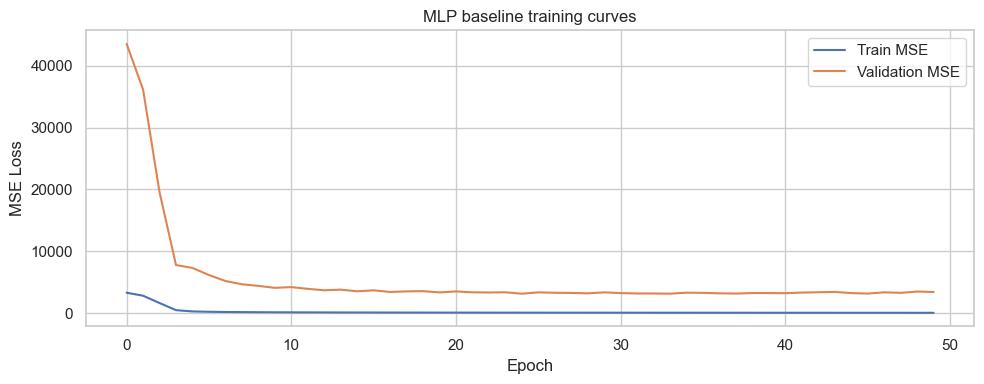

In [9]:
# Plot training/validation loss curves
plt.figure(figsize=(10, 4))
plt.plot(history["train_losses"], label="Train MSE")
plt.plot(history["val_losses"], label="Validation MSE")
plt.title("MLP baseline training curves")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Results and Interpretation

We evaluate all baseline models on the held-out test period using MAE and RMSE. This section includes both numerical results and a time-indexed plot of actual versus predicted prices for one specific week in the test set.

In [10]:
def predict_mlp(model: nn.Module, X: np.ndarray, device=DEVICE) -> np.ndarray:
    """Generate model predictions for a NumPy feature matrix."""
    model.eval()
    with torch.no_grad():
        x_tensor = torch.tensor(X, dtype=torch.float32, device=device)
        pred = model(x_tensor).squeeze(1).cpu().numpy()
    return pred


mlp_test_pred = predict_mlp(mlp, X_test_s, device=DEVICE)
mlp_mae, mlp_rmse = regression_metrics(y_test, mlp_test_pred)

mlp_row = pd.DataFrame([{"Model": "MLP baseline", "MAE": mlp_mae, "RMSE": mlp_rmse}])

# Idempotent final table for safe re-runs (no duplicate rows)
if "baseline_results_df" in globals():
    final_results_df = pd.concat([baseline_results_df, mlp_row], ignore_index=True)
else:
    # Fallback: rebuild from available scalar metrics if Section 7 wasn't re-run
    fallback_rows = [
        {"Model": "Persistence", "MAE": persistence_mae, "RMSE": persistence_rmse},
        {"Model": "Ridge Regression", "MAE": ridge_mae, "RMSE": ridge_rmse},
        {"Model": "Random Forest", "MAE": rf_mae, "RMSE": rf_rmse},
    ]
    final_results_df = pd.concat([pd.DataFrame(fallback_rows), mlp_row], ignore_index=True)

final_results_df = (
    final_results_df
    .drop_duplicates(subset=["Model"], keep="last")
    .sort_values("RMSE")
    .reset_index(drop=True)
)
display(final_results_df)

,Model,MAE,RMSE
0,Random Forest,4.931037,9.529023
1,MLP baseline,6.201206,10.473497
2,Ridge Regression,5.978535,11.302600
3,Persistence,6.984468,14.018992


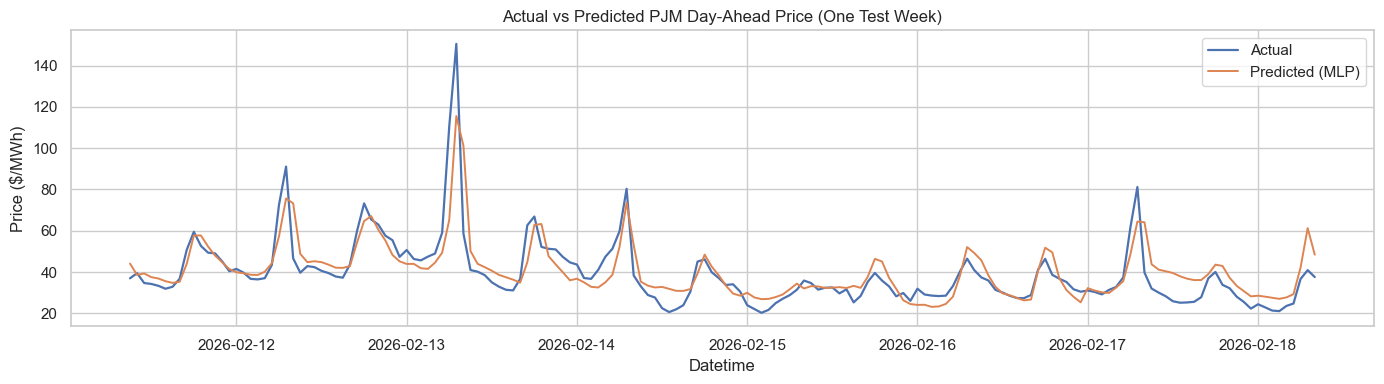

,actual_price,predicted_price
datetime_beginning_ept,,
2026-02-11 09:00:00,36.960207,44.095669
2026-02-11 10:00:00,39.450562,38.604870
2026-02-11 11:00:00,34.673281,39.311283
2026-02-11 12:00:00,34.241608,37.528889
2026-02-11 13:00:00,33.340777,36.874905


In [11]:
# Actual vs predicted for one week in the test period
pred_df = pd.DataFrame({
    "actual_price": y_test.values,
    "predicted_price": mlp_test_pred
}, index=y_test.index).sort_index()

# Use the first full week (168 hours) from the test set for visual interpretability
week_horizon = min(len(pred_df), 24 * 7)
week_df = pred_df.iloc[:week_horizon]

plt.figure(figsize=(14, 4))
plt.plot(week_df.index, week_df["actual_price"], label="Actual", linewidth=1.6)
plt.plot(week_df.index, week_df["predicted_price"], label="Predicted (MLP)", linewidth=1.4)
plt.title("Actual vs Predicted PJM Day-Ahead Price (One Test Week)")
plt.xlabel("Datetime")
plt.ylabel("Price ($/MWh)")
plt.legend()
plt.tight_layout()
plt.show()

display(week_df.head())

### Interpretation of Baseline Results

Based on the current run, baseline performance on the held-out test set is:

- **Random Forest:** MAE = 4.931, RMSE = 9.529
- **MLP baseline:** MAE = 6.201, RMSE = 10.473
- **Ridge Regression:** MAE = 5.979, RMSE = 11.303
- **Persistence:** MAE = 6.984, RMSE = 14.019

**Observed ranking by RMSE**

Random Forest -> MLP baseline -> Ridge Regression -> Persistence

**Observed ranking by MAE**

Random Forest -> Ridge Regression -> MLP baseline -> Persistence

**Did the MLP outperform sanity baselines?**

Yes. The MLP clearly outperformed the naive Persistence model and improved on Ridge in RMSE, but it did not beat Random Forest on either MAE or RMSE in this baseline configuration.

### Why Random Forest likely outperformed the current MLP

- **Tabular-data advantage:** Tree ensembles are often very strong on medium-sized tabular datasets with mixed nonlinear relationships and interactions.
- **Lower tuning sensitivity:** The current MLP is a lightly tuned baseline; neural nets typically need more architecture and optimization tuning to match tree-based performance on tabular data.
- **Spike handling via partitioning:** Random Forest can partition feature space into regimes, which can help capture conditional structure during volatile market periods.
- **Scale and sample efficiency:** With this data size and feature set, Random Forest can be more sample-efficient than an MLP that relies on gradient-based representation learning.

### What the one-week Actual vs Predicted plot shows

- The MLP captures the broad daily pattern and timing of many local peaks and troughs.
- The largest spike is underpredicted (the model follows the direction but smooths the magnitude).
- During low-price windows, predictions are often slightly high, indicating conservative smoothing toward central values.
- This behavior is consistent with the MLP learning average structure well but not fully capturing extreme regimes.

### Baseline Strengths and Weaknesses

**Strengths**

- Strong improvement over Persistence confirms that learned relationships beyond pure carry-forward are useful.
- Good overall tracking of hourly trend and recurring daily structure.
- Better RMSE than Ridge suggests useful nonlinear learning from the tabular feature set.

**Weaknesses**

- Underestimation of rare high-price spikes remains a key limitation.
- Some overprediction in trough periods suggests mean-reverting bias.
- Performance still trails Random Forest, indicating room for better temporal modeling and/or tuning.

**Why these weaknesses are expected**

A feedforward network consumes each row independently, so it can only leverage temporal information indirectly through engineered lag features. This limits its ability to model richer sequential dependencies, abrupt regime shifts, and multi-step temporal context.

## 11. Final Model Pipeline Setup

Below is the proposed end-to-end pipeline that will remain fixed while model classes evolve:

1. **Ingest and clean data** from PJM sources into a canonical hourly index.
2. **Feature construction** for demand, supply, calendar, cyclical, and lag variables.
3. **Chronological split** into train/validation/test periods to prevent leakage.
4. **Scaler fit on training only**, then transform validation/test with the same scaler.
5. **Model training loop** with reproducible seeds, optimizer settings, and early stopping.
6. **Evaluation suite** using MAE and RMSE on validation and test windows.
7. **Diagnostic plots** including learning curves and actual-vs-predicted timelines.
8. **Model comparison registry** to track baseline and future model variants consistently.

### Algorithmic Outline (Pseudocode)

```python
load raw_or_preprocessed_data()
enforce_datetime_index_and_sort()

X_train, y_train, X_val, y_val, X_test, y_test = chronological_split(data)

scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

for model in [Persistence, Ridge, RandomForest, MLP]:
    model.fit(train_data)
    val_pred  = model.predict(val_data)
    test_pred = model.predict(test_data)
    compute_and_store(MAE, RMSE)

select_candidate_models_based_on(validation_metrics)
run_final_evaluation_on(test_metrics)
generate_diagnostics(learning_curves, actual_vs_predicted_plots)
```

### Pipeline Components and Parameter Choices

- **Data scope:** hourly PJM records with engineered system and temporal predictors from Milestone 2.
- **Split policy:** 70/15/15 chronological split (train/validation/test).
- **Scaling:** StandardScaler fit on training features only.
- **Baselines:** Persistence (`price_lag_1`), Ridge (`alpha=1.0`), Random Forest (`n_estimators=250`, `min_samples_leaf=2`).
- **MLP baseline:** 2 hidden layers (128, 64), ReLU, Adam (`lr=1e-3`), MSELoss, early stopping (`patience=25`, `min_delta=1e-4`).
- **Primary metrics:** MAE and RMSE, with RMSE emphasized for spike sensitivity.

### Assumptions

- Hourly records are complete after preprocessing and dropping invalid rows.
- Current engineered predictors are available at forecast time (no post-hoc leakage).
- MAE and RMSE are sufficient for Milestone 3 baseline comparison.
- One held-out test block is acceptable for this milestone before expanding to rolling-origin evaluation.

### Preliminary Tuning Considerations for Final Models

- **Sequence window length:** test candidate lookback horizons (24h, 48h, 72h, 168h).
- **Model width/depth:** compare hidden dimensions (64, 128, 256) and number of layers.
- **Regularization:** tune dropout, weight decay, and early-stopping patience.
- **Optimization:** compare learning rates (1e-4 to 3e-3) and batch sizes (128 to 512).
- **Evaluation protocol:** move from single split to rolling-origin backtesting for robustness.

### Why this pipeline is submission-ready

This setup creates a reproducible and leakage-safe workflow from preprocessing to evaluation, while leaving model complexity as the only changing component. That separation is important for fair model comparison and for justifying future improvements in Milestone 4.

## 12. Future Directions

The next milestone will upgrade this baseline to sequence-aware architectures that explicitly model temporal dependencies. Planned directions:

- Build rolling input windows so each training example includes multiple prior hours instead of a single row snapshot.
- Compare recurrent architectures (RNN, GRU, LSTM) for memory of short-term and medium-term dynamics.
- Evaluate attention-based sequence alternatives if LSTM performance plateaus.
- Add targeted features for price spikes (extreme event indicators, weather integration if available).
- Use rolling-origin backtesting for more robust temporal generalization checks.

### Why sequence models are the next logical step

Electricity prices exhibit path dependence, regime shifts, and recurrent cycles. Sequence-aware models can learn these dynamics from ordered windows directly, reducing dependence on manually selected lag terms and potentially improving spike responsiveness.